📚 **Importación de libreías**

In [1]:
# 📚 **Importación de librerías**

from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    make_scorer,
)

# CatBoost
from catboost import CatBoostClassifier

# Para guardar modelos
from joblib import dump

# Configuración de visualización
plt.style.use("default")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# 💾 **Carga de datos**

# Cargar datos procesados desde Silver
data_path = Path("../../data/Silver")
dataset_file = data_path / "modelosvarcat.csv"

if not dataset_file.exists():
    print(f"❌ No se encontró el archivo: {dataset_file}")
    sys.exit(1)

df_original = pd.read_csv(dataset_file)

print(f"📊 Dataset original cargado exitosamente")
print(f"📊 Forma del dataset original: {df_original.shape}")

# Verificar distribución original
print(f"\n🎯 DISTRIBUCIÓN ORIGINAL DEL TARGET 'Atipico':")
print("=" * 45)
target_dist_original = df_original["Atipico"].value_counts().sort_index()
print(target_dist_original)
print(
    f"Proporción original de atípicos: {df_original['Atipico'].mean():.4f} ({df_original['Atipico'].mean() * 100:.2f}%)"
)

# 🔄 MUESTREO PARA REDUCIR VOLUMEN
print(f"\n🔄 APLICANDO MUESTREO ESTRATÉGICO:")
print("=" * 35)

# Separar por clase
df_atipicos = df_original[df_original["Atipico"] == 1]
df_normales = df_original[df_original["Atipico"] == 0]

print(f"Registros atípicos: {len(df_atipicos):,}")
print(f"Registros normales: {len(df_normales):,}")

# Mantener TODOS los atípicos y muestrear máximo 50,000 normales
MAX_NORMALES = 50000

if len(df_normales) > MAX_NORMALES:
    # Muestreo aleatorio estratificado de normales
    df_normales_sample = df_normales.sample(n=MAX_NORMALES, random_state=42)
    print(f"✂️ Muestreando {MAX_NORMALES:,} registros normales de {len(df_normales):,}")
else:
    df_normales_sample = df_normales
    print(f"✅ Manteniendo todos los {len(df_normales):,} registros normales")

# Combinar datasets
df = pd.concat([df_atipicos, df_normales_sample], ignore_index=True)

# Mezclar los datos
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 DATASET FINAL DESPUÉS DEL MUESTREO:")
print("=" * 45)
print(f"Forma del dataset: {df.shape}")
print(f"📋 Columnas: {list(df.columns)}")
print(f"💾 Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Verificar distribución del target después del muestreo
print(f"\n🎯 DISTRIBUCIÓN FINAL DEL TARGET 'Atipico':")
print("=" * 40)
target_dist = df["Atipico"].value_counts().sort_index()
print(target_dist)
print(
    f"Proporción final de atípicos: {df['Atipico'].mean():.4f} ({df['Atipico'].mean() * 100:.2f}%)"
)

# Mostrar reducción de datos
reduction_percent = (1 - len(df) / len(df_original)) * 100
print(f"\n📉 REDUCCIÓN DE DATOS:")
print("=" * 25)
print(f"Original: {len(df_original):,} registros")
print(f"Final: {len(df):,} registros")
print(f"Reducción: {reduction_percent:.1f}%")

# Verificar tipos de datos
print(f"\n📋 TIPOS DE DATOS:")
print("=" * 30)
print(df.dtypes.value_counts())

# Verificar valores faltantes
missing_values = df.isnull().sum().sum()
print(f"\n❌ Valores faltantes: {missing_values}")

if missing_values > 0:
    print("⚠️ Hay valores faltantes que deben ser tratados")
else:
    print("✅ No hay valores faltantes")

📊 Dataset original cargado exitosamente
📊 Forma del dataset original: (1537412, 25)

🎯 DISTRIBUCIÓN ORIGINAL DEL TARGET 'Atipico':
Atipico
0    1537009
1        403
Name: count, dtype: int64
Proporción original de atípicos: 0.0003 (0.03%)

🔄 APLICANDO MUESTREO ESTRATÉGICO:
Registros atípicos: 403
Registros normales: 1,537,009
✂️ Muestreando 50,000 registros normales de 1,537,009

📊 DATASET FINAL DESPUÉS DEL MUESTREO:
Forma del dataset: (50403, 25)
📋 Columnas: ['DepartamentoResidencia', 'DepartamentoMayorFrecuenciaCompra', 'RiesgoAlmacen', 'DepartamentoCredito', 'StatusComercioCredito', 'FrecuenciaCreditosSemana', 'CantidadCreditosUltimaSemana', 'TipoAlmacenCredito', 'TipoCliente', 'Atipico', 'dia_credito', 'mes_credito', 'hora_credito', 'dia_semana', 'es_dia_pago', 'es_noche_o_madrugada', 'frecuencia_categoria_alta', 'departamento_match_residencia_credito', 'cupo_alto_utilizado', 'ValorPagosUltimosMes_discretized', 'ValorCredito_discretized', 'CupoTotal_discretized', 'CupoDisponibleTot

In [3]:
# 🔧 **Preparación de datos**

# Separar features y target
X = df.drop("Atipico", axis=1)
y = df["Atipico"]

# Identificar tipos de variables
categorical_features = X.select_dtypes(include=["category", "object"]).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"📊 ANÁLISIS DE FEATURES:")
print("=" * 30)
print(f"Total features: {X.shape[1]}")
print(f"Variables categóricas: {len(categorical_features)}")
print(f"Variables numéricas: {len(numerical_features)}")

print(f"\n📋 Variables categóricas:")
for col in categorical_features:
    print(f"   • {col}: {X[col].nunique()} categorías únicas")

print(f"\n📋 Variables numéricas:")
for col in numerical_features:
    print(f"   • {col}: rango [{X[col].min():.2f}, {X[col].max():.2f}]")

# División estratificada train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 DIVISIÓN DE DATOS:")
print("=" * 25)
print(
    f"Train set: {X_train.shape[0]:,} registros ({X_train.shape[0] / len(df) * 100:.1f}%)"
)
print(
    f"Test set: {X_test.shape[0]:,} registros ({X_test.shape[0] / len(df) * 100:.1f}%)"
)

# Verificar distribución estratificada
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

print(f"\n🎯 DISTRIBUCIÓN ESTRATIFICADA:")
print("=" * 35)
print(f"Train - Normal: {train_dist[0]:.4f}, Atípico: {train_dist[1]:.4f}")
print(f"Test  - Normal: {test_dist[0]:.4f}, Atípico: {test_dist[1]:.4f}")
print("✅ Distribución estratificada mantenida")

📊 ANÁLISIS DE FEATURES:
Total features: 24
Variables categóricas: 8
Variables numéricas: 16

📋 Variables categóricas:
   • TipoAlmacenCredito: 2 categorías únicas
   • TipoCliente: 2 categorías únicas
   • ValorPagosUltimosMes_discretized: 5 categorías únicas
   • ValorCredito_discretized: 5 categorías únicas
   • CupoTotal_discretized: 5 categorías únicas
   • CupoDisponibleTotal_discretized: 5 categorías únicas
   • ValorAtipicoCliente_discretized: 5 categorías únicas
   • ValorAtipicoComercio_discretized: 5 categorías únicas

📋 Variables numéricas:
   • DepartamentoResidencia: rango [0.00, 35.00]
   • DepartamentoMayorFrecuenciaCompra: rango [3.00, 35.00]
   • RiesgoAlmacen: rango [1.00, 9.00]
   • DepartamentoCredito: rango [0.00, 35.00]
   • StatusComercioCredito: rango [1.00, 4.00]
   • FrecuenciaCreditosSemana: rango [1.00, 6.00]
   • CantidadCreditosUltimaSemana: rango [1.00, 10.00]
   • dia_credito: rango [1.00, 31.00]
   • mes_credito: rango [1.00, 12.00]
   • hora_credito: r

In [4]:
# ⚙️ **Funciones de preprocesamiento**


def prepare_data_for_catboost(X_train, X_test, categorical_features):
    """
    Preparar datos para CatBoost manteniendo categorías como texto
    """
    print("🔧 Preparando datos para CatBoost...")

    X_train_cat = X_train.copy()
    X_test_cat = X_test.copy()

    # Convertir categóricas a string para CatBoost
    for col in categorical_features:
        X_train_cat[col] = X_train_cat[col].astype(str)
        X_test_cat[col] = X_test_cat[col].astype(str)

    print(f"✅ Datos preparados para CatBoost")
    print(
        f"   • {len(categorical_features)} variables categóricas convertidas a string"
    )

    return X_train_cat, X_test_cat


def prepare_data_traditional(X_train, X_test, categorical_features, numerical_features):
    """
    Preparar datos para Logistic Regression y Random Forest
    """
    print("🔧 Preparando datos para modelos tradicionales...")

    X_train_prep = X_train.copy()
    X_test_prep = X_test.copy()

    # Label encoding para categóricas
    label_encoders = {}
    for col in categorical_features:
        le = LabelEncoder()
        X_train_prep[col] = le.fit_transform(X_train_prep[col].astype(str))
        X_test_prep[col] = le.transform(X_test_prep[col].astype(str))
        label_encoders[col] = le

    print(f"✅ Label encoding aplicado a {len(categorical_features)} variables")

    # Escalado para Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = X_train_prep.copy()
    X_test_scaled = X_test_prep.copy()

    if numerical_features:
        X_train_scaled[numerical_features] = scaler.fit_transform(
            X_train_prep[numerical_features]
        )
        X_test_scaled[numerical_features] = scaler.transform(
            X_test_prep[numerical_features]
        )
        print(f"✅ Escalado aplicado a {len(numerical_features)} variables numéricas")

    return (
        X_train_prep,
        X_test_prep,
        X_train_scaled,
        X_test_scaled,
        label_encoders,
        scaler,
    )


def evaluate_model_with_cv(model, X_train, y_train, cv_folds=5, random_state=42):
    """
    Evaluar modelo con cross validation
    """
    # Configurar cross validation
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    # Métricas a evaluar
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
    }

    # Realizar cross validation
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
    )

    # Calcular estadísticas
    cv_stats = {}
    for metric in scoring.keys():
        cv_stats[metric] = {
            "train_mean": cv_results[f"train_{metric}"].mean(),
            "train_std": cv_results[f"train_{metric}"].std(),
            "test_mean": cv_results[f"test_{metric}"].mean(),
            "test_std": cv_results[f"test_{metric}"].std(),
        }

    return cv_stats, cv_results


print("✅ Funciones de preprocesamiento definidas")

✅ Funciones de preprocesamiento definidas


In [5]:
# 🚀 **Preparación de datos para cada modelo**

print("🔄 PREPARANDO DATOS PARA TODOS LOS MODELOS")
print("=" * 50)

# Preparar datos para modelos tradicionales
X_train_prep, X_test_prep, X_train_scaled, X_test_scaled, label_encoders, scaler = (
    prepare_data_traditional(X_train, X_test, categorical_features, numerical_features)
)

# Preparar datos para CatBoost
X_train_cat, X_test_cat = prepare_data_for_catboost(
    X_train, X_test, categorical_features
)

print(f"\n📊 RESUMEN DE PREPARACIÓN:")
print("=" * 30)
print(f"Datos originales: {X_train.shape}")
print(f"Datos preparados (tradicional): {X_train_prep.shape}")
print(f"Datos escalados (LogReg): {X_train_scaled.shape}")
print(f"Datos para CatBoost: {X_train_cat.shape}")
print("✅ Todos los datos preparados correctamente")

🔄 PREPARANDO DATOS PARA TODOS LOS MODELOS
🔧 Preparando datos para modelos tradicionales...


✅ Label encoding aplicado a 8 variables
✅ Escalado aplicado a 16 variables numéricas
🔧 Preparando datos para CatBoost...
✅ Datos preparados para CatBoost
   • 8 variables categóricas convertidas a string

📊 RESUMEN DE PREPARACIÓN:
Datos originales: (40322, 24)
Datos preparados (tradicional): (40322, 24)
Datos escalados (LogReg): (40322, 24)
Datos para CatBoost: (40322, 24)
✅ Todos los datos preparados correctamente


In [6]:
# 🎯 **Definición de modelos**

print("🎯 CONFIGURANDO MODELOS")
print("=" * 25)

# Configuración de modelos
models_config = {
    "logistic_regression": {
        "model": LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced",  # Para manejar desbalance
        ),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "description": "Regresión Logística con escalado y balanceo de clases",
    },
    "random_forest": {
        "model": RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced",  # Para manejar desbalance
            n_jobs=-1,
        ),
        "X_train": X_train_prep,
        "X_test": X_test_prep,
        "description": "Random Forest con balanceo de clases",
    },
    "catboost": {
        "model": CatBoostClassifier(
            iterations=1000,
            random_state=42,
            verbose=100,
            cat_features=categorical_features,
            auto_class_weights="Balanced",  # Para manejar desbalance
            task_type="CPU",
            allow_writing_files=False,
            max_depth=6,
        ),
        "X_train": X_train_cat,
        "X_test": X_test_cat,
        "description": "CatBoost con manejo automático de categóricas y balanceo",
    },
}

print("📋 MODELOS CONFIGURADOS:")
for name, config in models_config.items():
    print(f"\n🔸 {name.replace('_', ' ').title()}:")
    print(f"   • {config['description']}")
    print(f"   • Datos de entrada: {config['X_train'].shape}")

print("\n✅ Configuración de modelos completada")

🎯 CONFIGURANDO MODELOS
📋 MODELOS CONFIGURADOS:

🔸 Logistic Regression:
   • Regresión Logística con escalado y balanceo de clases
   • Datos de entrada: (40322, 24)

🔸 Random Forest:
   • Random Forest con balanceo de clases
   • Datos de entrada: (40322, 24)

🔸 Catboost:
   • CatBoost con manejo automático de categóricas y balanceo
   • Datos de entrada: (40322, 24)

✅ Configuración de modelos completada


In [7]:
# 🏃‍♂️ **Entrenamiento con Cross Validation**

print("🏃‍♂️ INICIANDO ENTRENAMIENTO CON CROSS VALIDATION")
print("=" * 55)

# Configuración de CV
CV_FOLDS = 5
RANDOM_STATE = 42

# Almacenar resultados
cv_results_all = {}
final_models = {}

# Entrenar cada modelo
for model_name, model_config in models_config.items():
    print(f"\n🚀 ENTRENANDO: {model_name.replace('_', ' ').title()}")
    print("-" * 50)

    # Cross Validation
    print("📊 Ejecutando Cross Validation...")
    cv_stats, cv_raw = evaluate_model_with_cv(
        model_config["model"],
        model_config["X_train"],
        y_train,
        cv_folds=CV_FOLDS,
        random_state=RANDOM_STATE,
    )

    # Mostrar resultados de CV
    print("📈 Resultados de Cross Validation:")
    for metric, stats in cv_stats.items():
        print(
            f"   {metric:>8}: Train {stats['train_mean']:.4f}±{stats['train_std']:.4f} | "
            f"Val {stats['test_mean']:.4f}±{stats['test_std']:.4f}"
        )

    # Entrenar modelo final en todo el conjunto de entrenamiento
    print("🔧 Entrenando modelo final...")
    final_model = model_config["model"]
    final_model.fit(model_config["X_train"], y_train)

    # Evaluar en conjunto de prueba
    y_pred_test = final_model.predict(model_config["X_test"])

    # Calcular métricas en test
    test_metrics = {
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test),
        "recall": recall_score(y_test, y_pred_test),
        "f1": f1_score(y_test, y_pred_test),
        "roc_auc": roc_auc_score(y_test, y_pred_test),
    }

    print("🎯 Métricas en conjunto de prueba:")
    for metric, value in test_metrics.items():
        print(f"   {metric:>8}: {value:.4f}")

    # Almacenar resultados
    cv_results_all[model_name] = {
        "cv_stats": cv_stats,
        "cv_raw": cv_raw,
        "test_metrics": test_metrics,
        "model_config": model_config,
    }

    final_models[model_name] = final_model

    print(f"✅ {model_name} completado")

print(f"\n🎉 ENTRENAMIENTO COMPLETADO PARA {len(models_config)} MODELOS")

🏃‍♂️ INICIANDO ENTRENAMIENTO CON CROSS VALIDATION

🚀 ENTRENANDO: Logistic Regression
--------------------------------------------------
📊 Ejecutando Cross Validation...


📈 Resultados de Cross Validation:
   accuracy: Train 0.9670±0.0006 | Val 0.9673±0.0017
   precision: Train 0.1923±0.0027 | Val 0.1934±0.0080
     recall: Train 0.9775±0.0045 | Val 0.9721±0.0114
         f1: Train 0.3213±0.0040 | Val 0.3226±0.0113
    roc_auc: Train 0.9903±0.0015 | Val 0.9867±0.0071
🔧 Entrenando modelo final...
🎯 Métricas en conjunto de prueba:
   accuracy: 0.9664
   precision: 0.1854
     recall: 0.9383
         f1: 0.3096
    roc_auc: 0.9524
✅ logistic_regression completado

🚀 ENTRENANDO: Random Forest
--------------------------------------------------
📊 Ejecutando Cross Validation...
📈 Resultados de Cross Validation:
   accuracy: Train 1.0000±0.0000 | Val 0.9974±0.0004
   precision: Train 1.0000±0.0000 | Val 0.9873±0.0161
     recall: Train 1.0000±0.0000 | Val 0.6828±0.0572
         f1: Train 1.0000±0.0000 | Val 0.8057±0.0381
    roc_auc: Train 1.0000±0.0000 | Val 0.9847±0.0080
🔧 Entrenando modelo final...
🎯 Métricas en conjunto de prueba:
   accuracy: 0.9973
   prec

📊 ANÁLISIS DETALLADO DE CROSS VALIDATION
📈 PROMEDIOS DE CROSS VALIDATION:


,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.9673,0.1934,0.9721,0.3226,0.9867
random_forest,0.9974,0.9873,0.6828,0.8057,0.9847
catboost,0.9961,0.6997,0.9223,0.7937,0.9855



📊 DESVIACIONES ESTÁNDAR DE CROSS VALIDATION:


,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.0017,0.0080,0.0114,0.0113,0.0071
random_forest,0.0004,0.0161,0.0572,0.0381,0.0080
catboost,0.0008,0.0561,0.0243,0.0307,0.0110


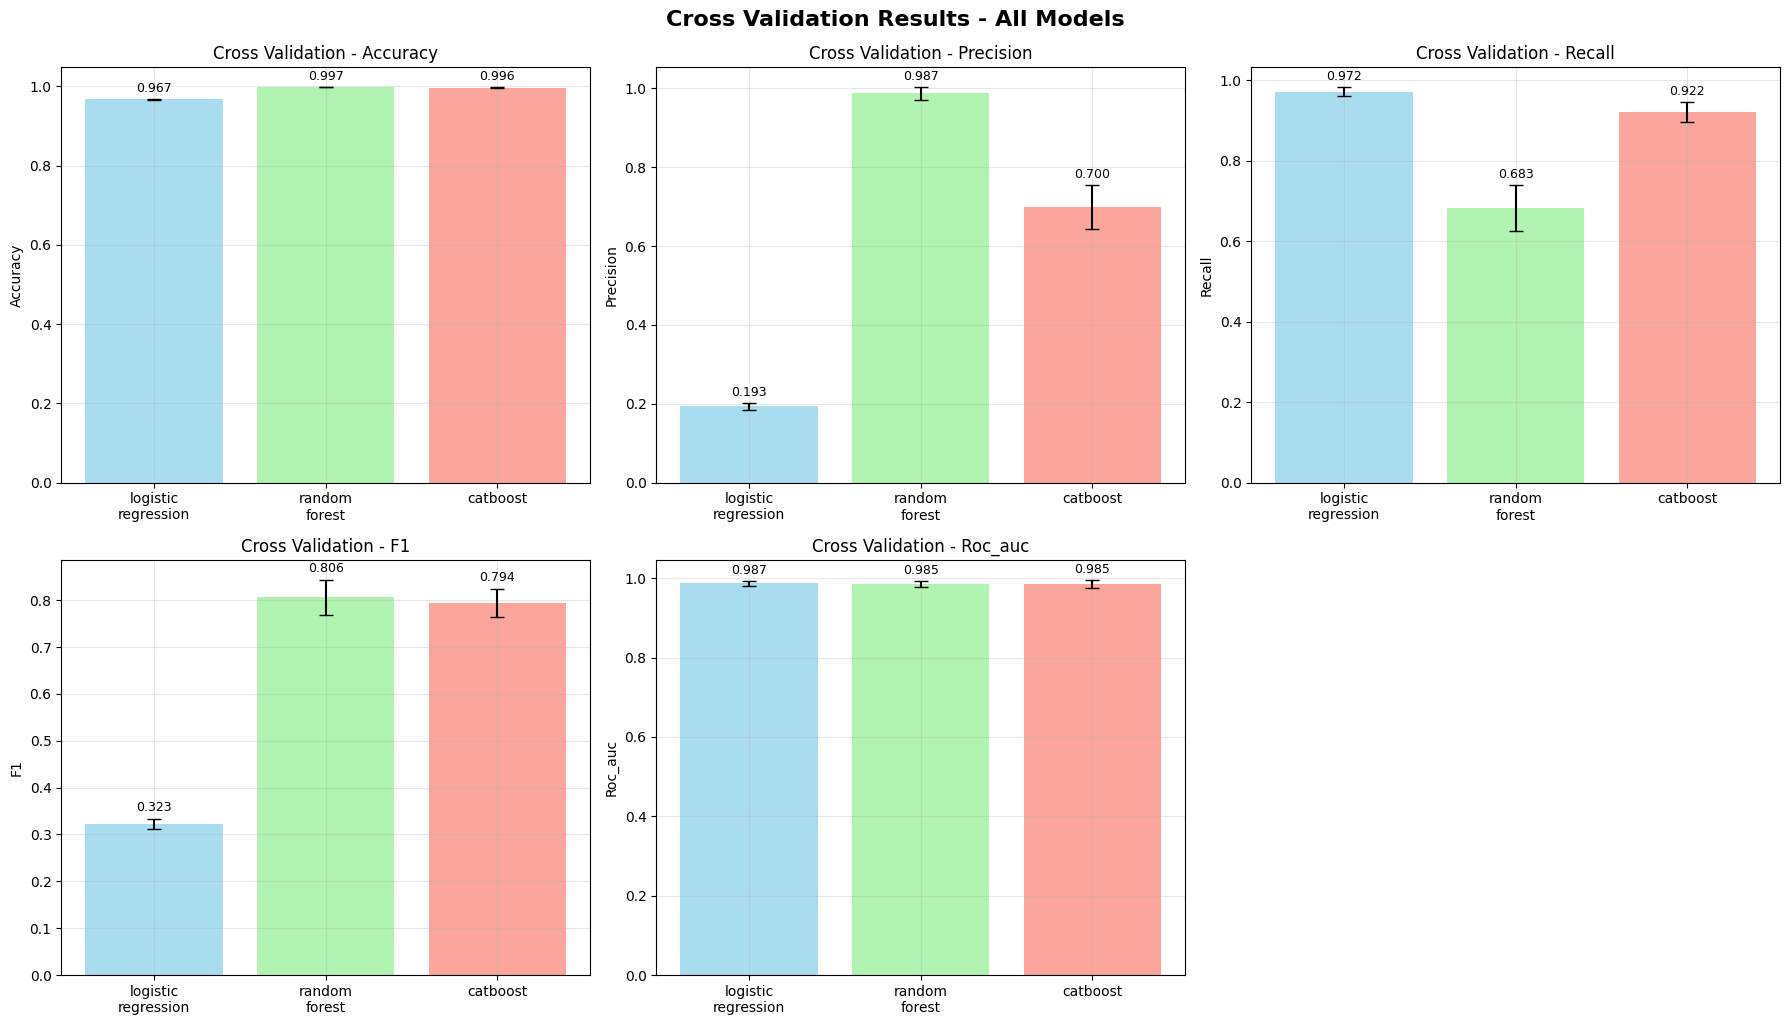

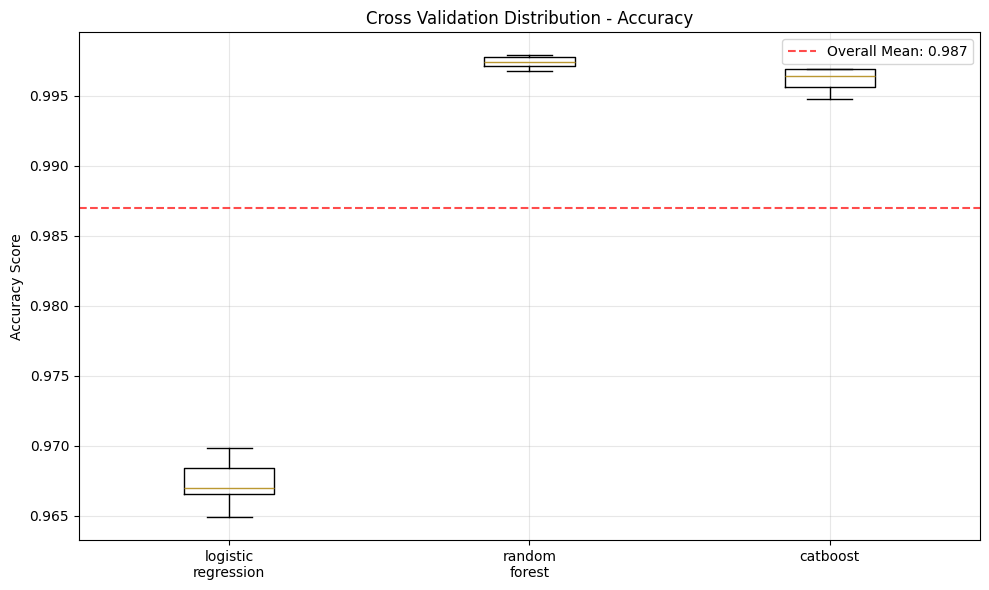

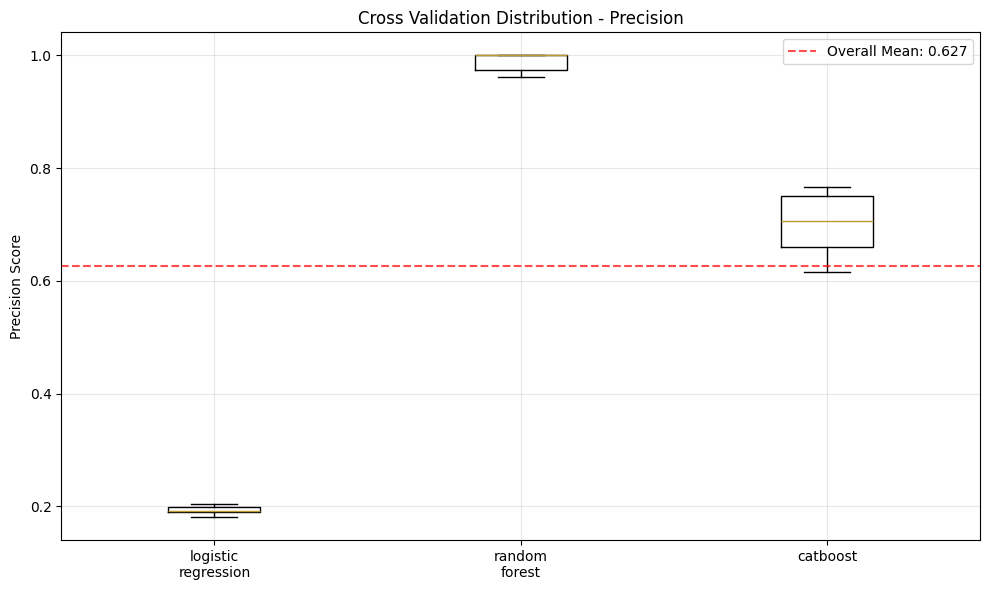

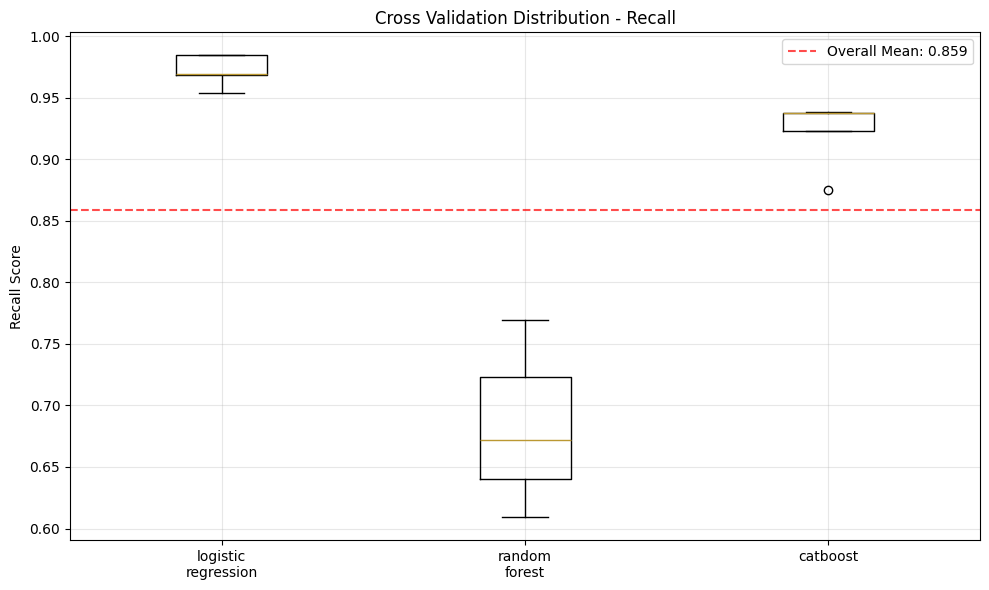

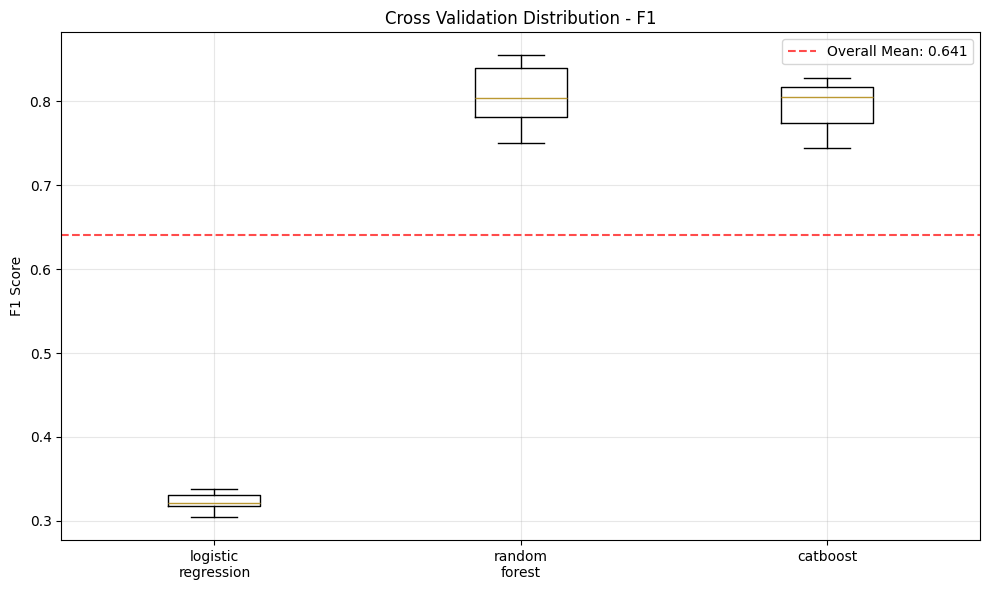

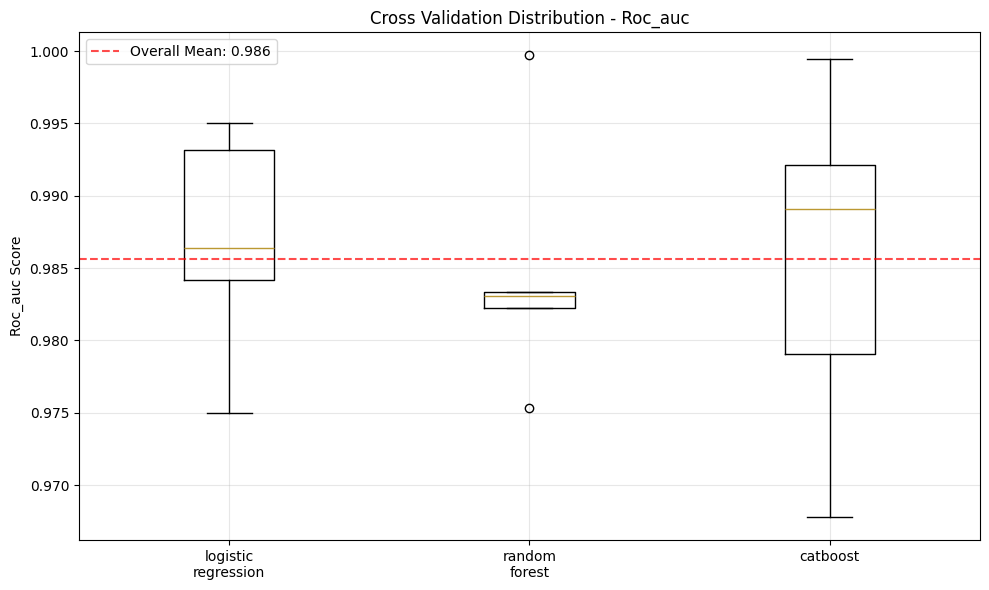

In [8]:
# 📊 **Análisis de Cross Validation**

print("📊 ANÁLISIS DETALLADO DE CROSS VALIDATION")
print("=" * 45)

# Crear DataFrames para análisis
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
models_names = list(cv_results_all.keys())

# DataFrame con medias de CV
cv_means = {}
cv_stds = {}

for metric in metrics:
    cv_means[metric] = {
        model: cv_results_all[model]["cv_stats"][metric]["test_mean"]
        for model in models_names
    }
    cv_stds[metric] = {
        model: cv_results_all[model]["cv_stats"][metric]["test_std"]
        for model in models_names
    }

df_cv_means = pd.DataFrame(cv_means)
df_cv_stds = pd.DataFrame(cv_stds)

print("📈 PROMEDIOS DE CROSS VALIDATION:")
print("=" * 35)
display(df_cv_means.round(4))

print("\n📊 DESVIACIONES ESTÁNDAR DE CROSS VALIDATION:")
print("=" * 45)
display(df_cv_stds.round(4))

# Gráficos de barras con error bars para CV
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    means = [df_cv_means.loc[model, metric] for model in models_names]
    stds = [df_cv_stds.loc[model, metric] for model in models_names]

    bars = axes[i].bar(
        range(len(models_names)),
        means,
        yerr=stds,
        capsize=5,
        alpha=0.7,
        color=["skyblue", "lightgreen", "salmon"],
    )

    axes[i].set_title(f"Cross Validation - {metric.capitalize()}")
    axes[i].set_ylabel(metric.capitalize())
    axes[i].set_xticks(range(len(models_names)))
    axes[i].set_xticklabels(
        [name.replace("_", "\n") for name in models_names], rotation=0
    )
    axes[i].grid(True, alpha=0.3)

    # Agregar valores en las barras
    for j, (mean, std) in enumerate(zip(means, stds)):
        axes[i].text(
            j, mean + std + 0.01, f"{mean:.3f}", ha="center", va="bottom", fontsize=9
        )

# Remover subplot extra
axes[-1].remove()

plt.tight_layout()
plt.suptitle(
    "Cross Validation Results - All Models", y=1.02, fontsize=16, fontweight="bold"
)
plt.show()

# Boxplots de CV para cada métrica
for metric in metrics:
    plt.figure(figsize=(10, 6))

    cv_data = []
    cv_labels = []

    for model_name in models_names:
        cv_scores = cv_results_all[model_name]["cv_raw"][f"test_{metric}"]
        cv_data.append(cv_scores)
        cv_labels.append(model_name.replace("_", "\n"))

    plt.boxplot(cv_data, labels=cv_labels)
    plt.title(f"Cross Validation Distribution - {metric.capitalize()}")
    plt.ylabel(f"{metric.capitalize()} Score")
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=0)

    # Agregar línea horizontal con la media general
    overall_mean = np.mean([np.mean(scores) for scores in cv_data])
    plt.axhline(
        overall_mean,
        color="red",
        linestyle="--",
        alpha=0.7,
        label=f"Overall Mean: {overall_mean:.3f}",
    )
    plt.legend()

    plt.tight_layout()
    plt.show()

🏆 COMPARACIÓN DE MÉTRICAS FINALES
🎯 MÉTRICAS EN CONJUNTO DE PRUEBA:


,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.9664,0.1854,0.9383,0.3096,0.9524
random_forest,0.9973,1.0000,0.6667,0.8000,0.8333
catboost,0.9965,0.7347,0.8889,0.8045,0.9431



🥇 MEJOR MODELO POR MÉTRICA:
  accuracy: Random Forest (0.9973)
 precision: Random Forest (1.0000)
    recall: Logistic Regression (0.9383)
        f1: Catboost (0.8045)
   roc_auc: Logistic Regression (0.9524)


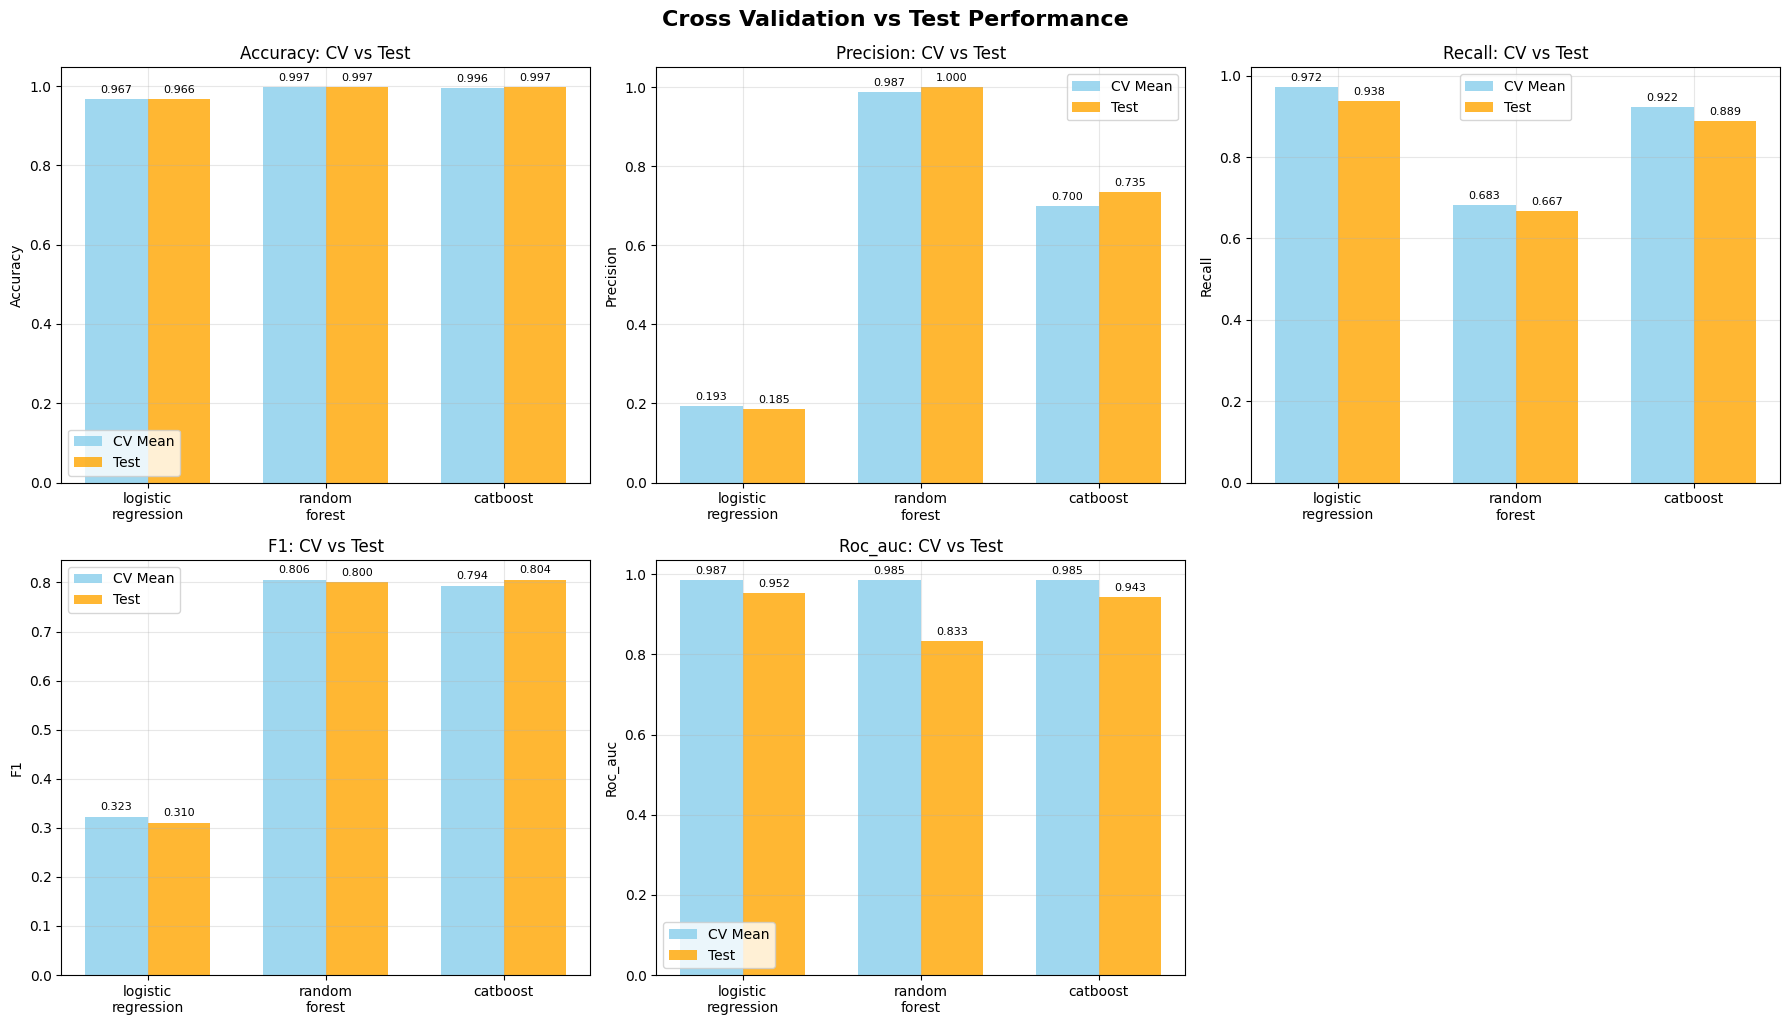


🏅 RANKING GENERAL (basado en F1-Score en Test):
1. Catboost: 0.8045
2. Random Forest: 0.8000
3. Logistic Regression: 0.3096


In [9]:
# 🏆 **Comparación de métricas finales**

print("🏆 COMPARACIÓN DE MÉTRICAS FINALES")
print("=" * 35)

# Crear DataFrame con métricas de test
test_metrics_df = {}
for metric in metrics:
    test_metrics_df[metric] = {
        model: cv_results_all[model]["test_metrics"][metric] for model in models_names
    }

df_test_metrics = pd.DataFrame(test_metrics_df)

print("🎯 MÉTRICAS EN CONJUNTO DE PRUEBA:")
print("=" * 35)
display(df_test_metrics.round(4))

# Identificar mejor modelo por cada métrica
print("\n🥇 MEJOR MODELO POR MÉTRICA:")
print("=" * 30)
for metric in metrics:
    best_model = df_test_metrics[metric].idxmax()
    best_score = df_test_metrics.loc[best_model, metric]
    print(f"{metric:>10}: {best_model.replace('_', ' ').title()} ({best_score:.4f})")

# Gráfico de comparación final (CV vs Test)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    # Datos de CV (media)
    cv_means = [df_cv_means.loc[model, metric] for model in models_names]
    # Datos de Test
    test_scores = [df_test_metrics.loc[model, metric] for model in models_names]

    x = np.arange(len(models_names))
    width = 0.35

    bars1 = axes[i].bar(
        x - width / 2, cv_means, width, label="CV Mean", alpha=0.8, color="skyblue"
    )
    bars2 = axes[i].bar(
        x + width / 2, test_scores, width, label="Test", alpha=0.8, color="orange"
    )

    axes[i].set_title(f"{metric.capitalize()}: CV vs Test")
    axes[i].set_ylabel(metric.capitalize())
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([name.replace("_", "\n") for name in models_names])
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

    # Agregar valores en las barras
    for bar in bars1:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    for bar in bars2:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

# Remover subplot extra
axes[-1].remove()

plt.tight_layout()
plt.suptitle(
    "Cross Validation vs Test Performance", y=1.02, fontsize=16, fontweight="bold"
)
plt.show()

# Calcular ranking general basado en F1-score
print("\n🏅 RANKING GENERAL (basado en F1-Score en Test):")
print("=" * 45)
f1_ranking = df_test_metrics["f1"].sort_values(ascending=False)
for i, (model, score) in enumerate(f1_ranking.items(), 1):
    print(f"{i}. {model.replace('_', ' ').title()}: {score:.4f}")

🏆 MEJOR MODELO SELECCIONADO: Catboost
📊 F1-Score en test: 0.8045
📈 Estabilidad CV (F1 std): 0.0307

📋 CLASSIFICATION REPORT - Catboost:
              precision    recall  f1-score   support

      Normal     0.9991    0.9974    0.9982     10000
     Atípico     0.7347    0.8889    0.8045        81

    accuracy                         0.9965     10081
   macro avg     0.8669    0.9431    0.9014     10081
weighted avg     0.9970    0.9965    0.9967     10081



<Figure size 800x600 with 0 Axes>

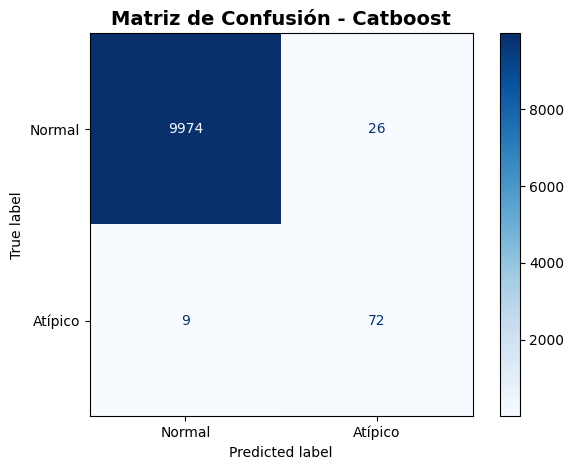


🔍 ANÁLISIS DE ERRORES:
True Negatives (TN):  9974 - Normales correctamente clasificadas
False Positives (FP):   26 - Normales clasificadas como atípicas
False Negatives (FN):    9 - Atípicas clasificadas como normales
True Positives (TP):    72 - Atípicas correctamente clasificadas

📊 TASAS DE ERROR:
Tasa de Falsos Positivos: 0.26% (26/10081)
Tasa de Falsos Negativos: 0.09% (9/10081)
Exactitud Global: 99.65%


In [10]:
# 🎖️ **Selección y evaluación del mejor modelo**

# Seleccionar mejor modelo basado en F1-score
best_model_name = df_test_metrics["f1"].idxmax()
best_model = final_models[best_model_name]
best_model_config = cv_results_all[best_model_name]["model_config"]
y_pred_best = best_model.predict(best_model_config["X_test"])

print(f"🏆 MEJOR MODELO SELECCIONADO: {best_model_name.replace('_', ' ').title()}")
print("=" * 60)
print(
    f"📊 F1-Score en test: {cv_results_all[best_model_name]['test_metrics']['f1']:.4f}"
)
print(
    f"📈 Estabilidad CV (F1 std): {cv_results_all[best_model_name]['cv_stats']['f1']['test_std']:.4f}"
)

# Classification Report detallado
print(f"\n📋 CLASSIFICATION REPORT - {best_model_name.replace('_', ' ').title()}:")
print("=" * 70)
print(
    classification_report(
        y_test, y_pred_best, target_names=["Normal", "Atípico"], digits=4
    )
)

# Matriz de confusión
plt.figure(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=["Normal", "Atípico"],
    cmap="Blues",
    values_format="d",
)
plt.title(
    f"Matriz de Confusión - {best_model_name.replace('_', ' ').title()}",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Análisis de errores
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"\n🔍 ANÁLISIS DE ERRORES:")
print("=" * 25)
print(f"True Negatives (TN):  {tn:4d} - Normales correctamente clasificadas")
print(f"False Positives (FP): {fp:4d} - Normales clasificadas como atípicas")
print(f"False Negatives (FN): {fn:4d} - Atípicas clasificadas como normales")
print(f"True Positives (TP):  {tp:4d} - Atípicas correctamente clasificadas")

print(f"\n📊 TASAS DE ERROR:")
print("=" * 20)
total = len(y_test)
print(f"Tasa de Falsos Positivos: {fp / total * 100:.2f}% ({fp}/{total})")
print(f"Tasa de Falsos Negativos: {fn / total * 100:.2f}% ({fn}/{total})")
print(f"Exactitud Global: {(tp + tn) / total * 100:.2f}%")

📈 GENERANDO CURVAS DE EVALUACIÓN


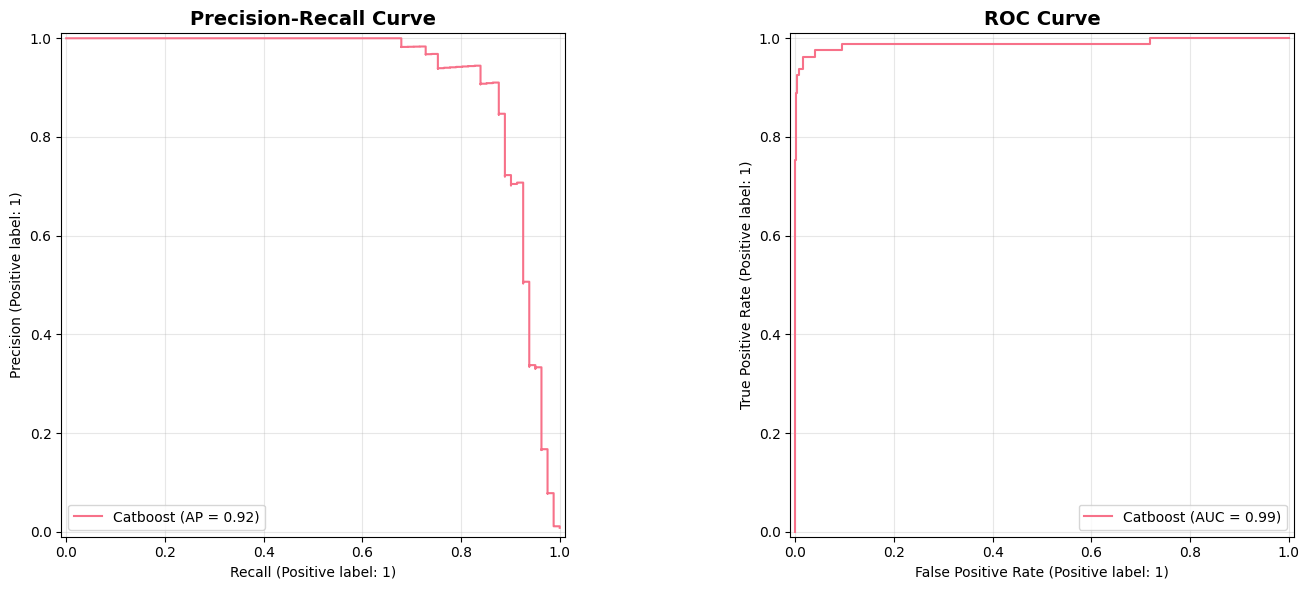

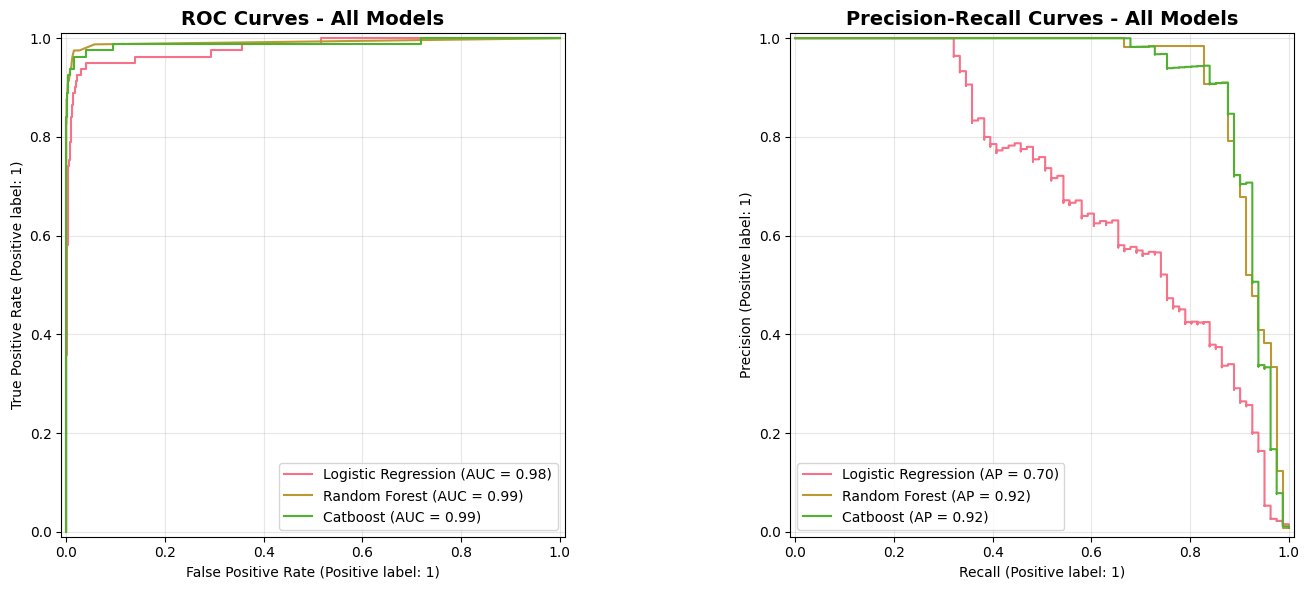

✅ Curvas de evaluación generadas


In [11]:
# 📈 **Curvas de evaluación**

print("📈 GENERANDO CURVAS DE EVALUACIÓN")
print("=" * 35)

# Verificar si el modelo tiene predict_proba
if hasattr(best_model, "predict_proba"):
    y_proba_best = best_model.predict_proba(best_model_config["X_test"])[:, 1]
    has_proba = True
else:
    y_proba_best = y_pred_best
    has_proba = False
    print("⚠️ Modelo no soporta probabilidades, usando predicciones binarias")

# Crear subplots para las curvas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Precision-Recall Curve
if has_proba:
    pr_display = PrecisionRecallDisplay.from_predictions(
        y_test, y_proba_best, ax=axes[0], name=best_model_name.replace("_", " ").title()
    )
else:
    pr_display = PrecisionRecallDisplay.from_predictions(
        y_test, y_pred_best, ax=axes[0], name=best_model_name.replace("_", " ").title()
    )

axes[0].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[0].grid(True, alpha=0.3)

# ROC Curve
if has_proba:
    roc_display = RocCurveDisplay.from_predictions(
        y_test, y_proba_best, ax=axes[1], name=best_model_name.replace("_", " ").title()
    )
else:
    roc_display = RocCurveDisplay.from_predictions(
        y_test, y_pred_best, ax=axes[1], name=best_model_name.replace("_", " ").title()
    )

axes[1].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Curvas para todos los modelos en una sola figura
if has_proba:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ROC curves para todos los modelos
    for model_name in models_names:
        model = final_models[model_name]
        model_config = cv_results_all[model_name]["model_config"]

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(model_config["X_test"])[:, 1]

            RocCurveDisplay.from_predictions(
                y_test,
                y_proba,
                ax=axes[0],
                name=f"{model_name.replace('_', ' ').title()}",
            )

            PrecisionRecallDisplay.from_predictions(
                y_test,
                y_proba,
                ax=axes[1],
                name=f"{model_name.replace('_', ' ').title()}",
            )

    axes[0].set_title("ROC Curves - All Models", fontsize=14, fontweight="bold")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title(
        "Precision-Recall Curves - All Models", fontsize=14, fontweight="bold"
    )
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✅ Curvas de evaluación generadas")

In [12]:
# 💾 **Guardar modelo y resultados**

print("💾 GUARDANDO MODELO Y RESULTADOS")
print("=" * 35)

# Crear carpetas si no existen
models_path = Path("../../models")
results_path = Path("../../results")

models_path.mkdir(parents=True, exist_ok=True)
results_path.mkdir(parents=True, exist_ok=True)

# Guardar mejor modelo
model_filename = f"atypical_detection_{best_model_name}_v1.joblib"
model_path = models_path / model_filename

dump(best_model, model_path)
print(f"✅ Modelo guardado: {model_path}")

# Guardar preprocessors si existen
if best_model_name == "logistic_regression":
    scaler_path = models_path / f"scaler_{best_model_name}_v1.joblib"
    dump(scaler, scaler_path)
    print(f"✅ Scaler guardado: {scaler_path}")

if best_model_name in ["logistic_regression", "random_forest"]:
    encoders_path = models_path / f"label_encoders_{best_model_name}_v1.joblib"
    dump(label_encoders, encoders_path)
    print(f"✅ Label encoders guardados: {encoders_path}")

# Guardar resultados de CV
cv_results_summary = {
    "best_model": best_model_name,
    "cv_results": df_cv_means.to_dict(),
    "cv_stds": df_cv_stds.to_dict(),
    "test_metrics": df_test_metrics.to_dict(),
    "model_configs": {
        name: str(config["model"]) for name, config in models_config.items()
    },
    "training_info": {
        "cv_folds": CV_FOLDS,
        "random_state": RANDOM_STATE,
        "test_size": 0.2,
        "stratified": True,
    },
}

results_file = results_path / f"training_results_{best_model_name}_v1.json"
import json

with open(results_file, "w") as f:
    json.dump(cv_results_summary, f, indent=2)

print(f"✅ Resultados guardados: {results_file}")

# Resumen final
print(f"\n🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
print("=" * 45)
print(f"🏆 Mejor modelo: {best_model_name.replace('_', ' ').title()}")
print(f"📊 Métricas del mejor modelo:")
for metric, value in cv_results_all[best_model_name]["test_metrics"].items():
    print(f"   • {metric.capitalize()}: {value:.4f}")

print(f"\n📁 Archivos generados:")
print(f"   • {model_path}")
if best_model_name == "logistic_regression":
    print(f"   • {scaler_path}")
if best_model_name in ["logistic_regression", "random_forest"]:
    print(f"   • {encoders_path}")
print(f"   • {results_file}")

print(f"\n✅ Proceso completado. El modelo está listo para producción.")

💾 GUARDANDO MODELO Y RESULTADOS
✅ Modelo guardado: ../../models/atypical_detection_catboost_v1.joblib
✅ Resultados guardados: ../../results/training_results_catboost_v1.json

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🏆 Mejor modelo: Catboost
📊 Métricas del mejor modelo:
   • Accuracy: 0.9965
   • Precision: 0.7347
   • Recall: 0.8889
   • F1: 0.8045
   • Roc_auc: 0.9431

📁 Archivos generados:
   • ../../models/atypical_detection_catboost_v1.joblib
   • ../../results/training_results_catboost_v1.json

✅ Proceso completado. El modelo está listo para producción.


In [13]:
# 🧪 **EVALUACIÓN EN DATASET COMPLETO**

print("🧪 EVALUACIÓN DEL MEJOR MODELO EN DATASET COMPLETO")
print("=" * 60)

# Cargar modelo y preprocessors guardados
from joblib import load
import json

models_path = Path("../../models")
results_path = Path("../../results")

# Cargar información del mejor modelo
results_file = results_path / f"training_results_{best_model_name}_v1.json"
with open(results_file, "r") as f:
    training_results = json.load(f)

print(f"📋 INFORMACIÓN DEL MODELO:")
print("=" * 30)
print(f"Mejor modelo: {best_model_name.replace('_', ' ').title()}")
print(
    f"F1-Score en entrenamiento: {training_results['test_metrics']['f1'][best_model_name]:.4f}"
)
print(
    f"Recall en entrenamiento: {training_results['test_metrics']['recall'][best_model_name]:.4f}"
)

# Cargar modelo entrenado
model_path = models_path / f"atypical_detection_{best_model_name}_v1.joblib"
trained_model = load(model_path)
print(f"✅ Modelo cargado desde: {model_path}")

# Cargar preprocessors si existen
trained_scaler = None
trained_encoders = None

if best_model_name == "logistic_regression":
    scaler_path = models_path / f"scaler_{best_model_name}_v1.joblib"
    trained_scaler = load(scaler_path)
    print(f"✅ Scaler cargado desde: {scaler_path}")

if best_model_name in ["logistic_regression", "random_forest"]:
    encoders_path = models_path / f"label_encoders_{best_model_name}_v1.joblib"
    trained_encoders = load(encoders_path)
    print(f"✅ Label encoders cargados desde: {encoders_path}")

print("\n✅ Todos los componentes del modelo cargados correctamente")

🧪 EVALUACIÓN DEL MEJOR MODELO EN DATASET COMPLETO
📋 INFORMACIÓN DEL MODELO:
Mejor modelo: Catboost
F1-Score en entrenamiento: 0.8045
Recall en entrenamiento: 0.8889
✅ Modelo cargado desde: ../../models/atypical_detection_catboost_v1.joblib

✅ Todos los componentes del modelo cargados correctamente


In [14]:
# 🗃️ **PREPARACIÓN DEL DATASET COMPLETO**

print("\n🗃️ PREPARANDO DATASET COMPLETO PARA EVALUACIÓN")
print("=" * 55)

# Separar features y target del dataset original completo
X_full = df_original.drop("Atipico", axis=1)
y_full = df_original["Atipico"]

print(f"📊 DATASET COMPLETO:")
print("=" * 25)
print(f"Total registros: {len(df_original):,}")
print(f"Features: {X_full.shape[1]}")
print(f"Memoria: {df_original.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Verificar distribución del target completo
print(f"\n🎯 DISTRIBUCIÓN COMPLETA DEL TARGET:")
print("=" * 40)
full_target_dist = y_full.value_counts().sort_index()
print(full_target_dist)
print(f"Proporción de atípicos: {y_full.mean():.4f} ({y_full.mean() * 100:.2f}%)")

# Identificar features categóricas y numéricas del dataset completo
categorical_features_full = X_full.select_dtypes(
    include=["category", "object"]
).columns.tolist()
numerical_features_full = X_full.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n📋 ANÁLISIS DE FEATURES COMPLETO:")
print("=" * 35)
print(f"Variables categóricas: {len(categorical_features_full)}")
print(f"Variables numéricas: {len(numerical_features_full)}")

# Verificar consistencia con el entrenamiento
if categorical_features_full != categorical_features:
    print("⚠️ Las features categóricas difieren del entrenamiento")
if numerical_features_full != numerical_features:
    print("⚠️ Las features numéricas difieren del entrenamiento")

print("✅ Dataset completo preparado para evaluación")


🗃️ PREPARANDO DATASET COMPLETO PARA EVALUACIÓN


📊 DATASET COMPLETO:
Total registros: 1,537,412
Features: 24
Memoria: 939.2 MB

🎯 DISTRIBUCIÓN COMPLETA DEL TARGET:
Atipico
0    1537009
1        403
Name: count, dtype: int64
Proporción de atípicos: 0.0003 (0.03%)

📋 ANÁLISIS DE FEATURES COMPLETO:
Variables categóricas: 8
Variables numéricas: 16
✅ Dataset completo preparado para evaluación


In [15]:
# ⚙️ **FUNCIÓN DE PREPROCESAMIENTO PARA DATASET COMPLETO**


def preprocess_full_dataset(
    X_full, model_name, trained_encoders=None, trained_scaler=None
):
    """
    Preprocesar dataset completo usando los mismos transformadores del entrenamiento
    """
    print(
        f"🔧 Preprocesando dataset completo para {model_name.replace('_', ' ').title()}..."
    )

    X_processed = X_full.copy()

    if model_name == "catboost":
        # Para CatBoost: convertir categóricas a string
        for col in categorical_features_full:
            X_processed[col] = X_processed[col].astype(str)
        print(f"✅ Variables categóricas convertidas a string para CatBoost")

    elif model_name in ["logistic_regression", "random_forest"]:
        # Para modelos tradicionales: aplicar label encoding
        if trained_encoders is None:
            raise ValueError("Se requieren los label encoders entrenados")

        for col in categorical_features_full:
            le = trained_encoders[col]
            # Manejar categorías no vistas durante el entrenamiento
            X_processed[col] = X_processed[col].astype(str)

            # Mapear categorías no vistas a una categoría desconocida
            known_classes = set(le.classes_)
            unknown_mask = ~X_processed[col].isin(known_classes)

            if unknown_mask.any():
                print(
                    f"⚠️ {col}: {unknown_mask.sum():,} valores no vistos en entrenamiento"
                )
                # Asignar la primera clase conocida a valores desconocidos
                X_processed.loc[unknown_mask, col] = le.classes_[0]

            X_processed[col] = le.transform(X_processed[col])

        print(
            f"✅ Label encoding aplicado a {len(categorical_features_full)} variables"
        )

        # Para Logistic Regression: aplicar escalado
        if model_name == "logistic_regression":
            if trained_scaler is None:
                raise ValueError("Se requiere el scaler entrenado")

            if numerical_features_full:
                X_processed[numerical_features_full] = trained_scaler.transform(
                    X_processed[numerical_features_full]
                )
                print(
                    f"✅ Escalado aplicado a {len(numerical_features_full)} variables numéricas"
                )

    print(f"✅ Preprocesamiento completado para {X_processed.shape[0]:,} registros")
    return X_processed


# Preprocesar el dataset completo
print("\n🔄 APLICANDO PREPROCESAMIENTO AL DATASET COMPLETO")
print("=" * 55)

X_full_processed = preprocess_full_dataset(
    X_full, best_model_name, trained_encoders, trained_scaler
)

print(f"\n📊 DATASET PROCESADO:")
print("=" * 25)
print(f"Forma original: {X_full.shape}")
print(f"Forma procesada: {X_full_processed.shape}")
print("✅ Preprocesamiento completado exitosamente")


🔄 APLICANDO PREPROCESAMIENTO AL DATASET COMPLETO
🔧 Preprocesando dataset completo para Catboost...
✅ Variables categóricas convertidas a string para CatBoost
✅ Preprocesamiento completado para 1,537,412 registros

📊 DATASET PROCESADO:
Forma original: (1537412, 24)
Forma procesada: (1537412, 24)
✅ Preprocesamiento completado exitosamente


In [16]:
# 🚀 **EVALUACIÓN COMPLETA DEL MODELO**

print("\n🚀 EVALUANDO MODELO EN DATASET COMPLETO")
print("=" * 45)

# Realizar predicciones
print("🔮 Realizando predicciones...")
y_pred_full = trained_model.predict(X_full_processed)

# Calcular probabilidades si está disponible
has_proba_full = hasattr(trained_model, "predict_proba")
if has_proba_full:
    y_proba_full = trained_model.predict_proba(X_full_processed)[:, 1]
    print("✅ Probabilidades calculadas")
else:
    y_proba_full = y_pred_full
    print("⚠️ Modelo no soporta probabilidades")

# Calcular métricas completas
full_metrics = {
    "accuracy": accuracy_score(y_full, y_pred_full),
    "precision": precision_score(y_full, y_pred_full),
    "recall": recall_score(y_full, y_pred_full),
    "f1": f1_score(y_full, y_pred_full),
    "roc_auc": roc_auc_score(y_full, y_proba_full if has_proba_full else y_pred_full),
}

print(f"\n📊 MÉTRICAS EN DATASET COMPLETO:")
print("=" * 35)
for metric, value in full_metrics.items():
    training_value = training_results["test_metrics"][metric][best_model_name]
    diff = value - training_value
    arrow = "📈" if diff > 0 else "📉" if diff < 0 else "➡️"
    print(f"{metric:>10}: {value:.4f} {arrow} (Δ{diff:+.4f} vs training)")

# Análisis crítico para banca
print(f"\n🚨 ANÁLISIS CRÍTICO PARA DETECCIÓN DE FRAUDES:")
print("=" * 50)
recall_full = full_metrics["recall"]
if recall_full >= 0.90:
    recall_status = "🟢 EXCELENTE - Detecta >90% de fraudes"
elif recall_full >= 0.80:
    recall_status = "🟡 BUENO - Detecta >80% de fraudes"
elif recall_full >= 0.70:
    recall_status = "🟠 REGULAR - Detecta >70% de fraudes"
else:
    recall_status = "🔴 CRÍTICO - Detecta <70% de fraudes"

print(f"Recall: {recall_full:.4f} ({recall_full * 100:.1f}%) - {recall_status}")

# Calcular matriz de confusión completa
cm_full = confusion_matrix(y_full, y_pred_full)
tn_full, fp_full, fn_full, tp_full = cm_full.ravel()

print(f"\n🔍 ANÁLISIS DE ERRORES EN DATASET COMPLETO:")
print("=" * 45)
print(f"True Negatives (TN):  {tn_full:,} - Normales correctamente clasificadas")
print(f"False Positives (FP): {fp_full:,} - Normales clasificadas como atípicas")
print(f"False Negatives (FN): {fn_full:,} - Atípicas NO detectadas (¡CRÍTICO!)")
print(f"True Positives (TP):  {tp_full:,} - Atípicas correctamente detectadas")

total_full = len(y_full)
print(f"\n📊 TASAS DE ERROR COMPLETAS:")
print("=" * 30)
print(
    f"Tasa de Falsos Positivos: {fp_full / total_full * 100:.2f}% ({fp_full:,}/{total_full:,})"
)
print(
    f"Tasa de Falsos Negativos: {fn_full / total_full * 100:.2f}% ({fn_full:,}/{total_full:,})"
)
print(f"Exactitud Global: {(tp_full + tn_full) / total_full * 100:.2f}%")

# Impacto financiero estimado (ejemplo)
print(f"\n💰 ESTIMACIÓN DE IMPACTO FINANCIERO:")
print("=" * 40)
avg_fraud_amount = 1000  # Monto promedio de fraude (ajustar según datos reales)
total_fraud_missed = fn_full * avg_fraud_amount
total_false_alerts = fp_full * 10  # Costo promedio de investigar falsa alarma

print(
    f"Fraudes no detectados: {fn_full:,} × ${avg_fraud_amount:,} = ${total_fraud_missed:,}"
)
print(f"Costo de falsas alarmas: {fp_full:,} × $10 = ${total_false_alerts:,}")
print(f"Impacto total estimado: ${total_fraud_missed + total_false_alerts:,}")


🚀 EVALUANDO MODELO EN DATASET COMPLETO
🔮 Realizando predicciones...
✅ Probabilidades calculadas

📊 MÉTRICAS EN DATASET COMPLETO:
  accuracy: 0.9974 📈 (Δ+0.0009 vs training)
 precision: 0.0902 📉 (Δ-0.6445 vs training)
    recall: 0.9777 📈 (Δ+0.0888 vs training)
        f1: 0.1652 📉 (Δ-0.6392 vs training)
   roc_auc: 0.9977 📈 (Δ+0.0546 vs training)

🚨 ANÁLISIS CRÍTICO PARA DETECCIÓN DE FRAUDES:
Recall: 0.9777 (97.8%) - 🟢 EXCELENTE - Detecta >90% de fraudes

🔍 ANÁLISIS DE ERRORES EN DATASET COMPLETO:
True Negatives (TN):  1,533,037 - Normales correctamente clasificadas
False Positives (FP): 3,972 - Normales clasificadas como atípicas
False Negatives (FN): 9 - Atípicas NO detectadas (¡CRÍTICO!)
True Positives (TP):  394 - Atípicas correctamente detectadas

📊 TASAS DE ERROR COMPLETAS:
Tasa de Falsos Positivos: 0.26% (3,972/1,537,412)
Tasa de Falsos Negativos: 0.00% (9/1,537,412)
Exactitud Global: 99.74%

💰 ESTIMACIÓN DE IMPACTO FINANCIERO:
Fraudes no detectados: 9 × $1,000 = $9,000
Costo d


📊 GENERANDO VISUALIZACIONES COMPLETAS


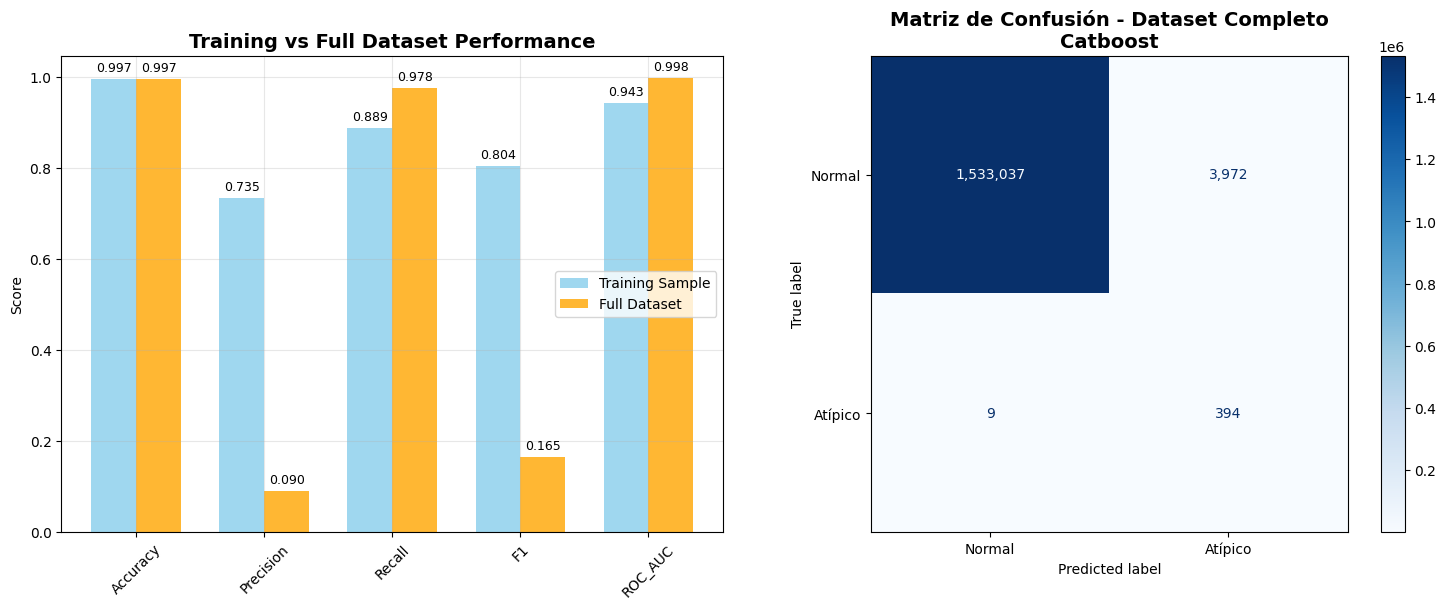


📈 ANÁLISIS DE RECALL POR VOLUMEN DE DATOS:
Training Sample (50,403 registros): Recall = 0.8889
Full Dataset    (1,537,412 registros): Recall = 0.9777
Diferencia: +0.0888
Estabilidad: 🟡 BUENO - Ligera variación


In [17]:
# 📊 **VISUALIZACIONES DEL RENDIMIENTO COMPLETO**

print("\n📊 GENERANDO VISUALIZACIONES COMPLETAS")
print("=" * 45)

# Comparación: Training vs Full Dataset
metrics_comparison = pd.DataFrame(
    {
        "Training": [
            training_results["test_metrics"][metric][best_model_name]
            for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]
        ],
        "Full_Dataset": [
            full_metrics[metric]
            for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]
        ],
    },
    index=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
)

# Gráfico de comparación
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras comparativo
x = np.arange(len(metrics_comparison.index))
width = 0.35

bars1 = axes[0].bar(
    x - width / 2,
    metrics_comparison["Training"],
    width,
    label="Training Sample",
    alpha=0.8,
    color="skyblue",
)
bars2 = axes[0].bar(
    x + width / 2,
    metrics_comparison["Full_Dataset"],
    width,
    label="Full Dataset",
    alpha=0.8,
    color="orange",
)

axes[0].set_title(
    "Training vs Full Dataset Performance", fontsize=14, fontweight="bold"
)
axes[0].set_ylabel("Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_comparison.index, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Agregar valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

# Matriz de confusión del dataset completo
cm_display_full = ConfusionMatrixDisplay(
    confusion_matrix=cm_full, display_labels=["Normal", "Atípico"]
)
cm_display_full.plot(ax=axes[1], cmap="Blues", values_format=",d")
axes[1].set_title(
    f"Matriz de Confusión - Dataset Completo\n{best_model_name.replace('_', ' ').title()}",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# Análisis de recall por volumen
print(f"\n📈 ANÁLISIS DE RECALL POR VOLUMEN DE DATOS:")
print("=" * 45)
training_recall = training_results["test_metrics"]["recall"][best_model_name]
full_recall = full_metrics["recall"]
training_size = len(df)  # Dataset de entrenamiento reducido
full_size = len(df_original)  # Dataset completo

print(f"Training Sample ({training_size:,} registros): Recall = {training_recall:.4f}")
print(f"Full Dataset    ({full_size:,} registros): Recall = {full_recall:.4f}")
print(f"Diferencia: {full_recall - training_recall:+.4f}")

if abs(full_recall - training_recall) < 0.05:
    stability = "🟢 EXCELENTE - Modelo estable"
elif abs(full_recall - training_recall) < 0.10:
    stability = "🟡 BUENO - Ligera variación"
else:
    stability = "🔴 PREOCUPANTE - Alta variación"

print(f"Estabilidad: {stability}")


📈 GENERANDO CURVAS COMPLETAS


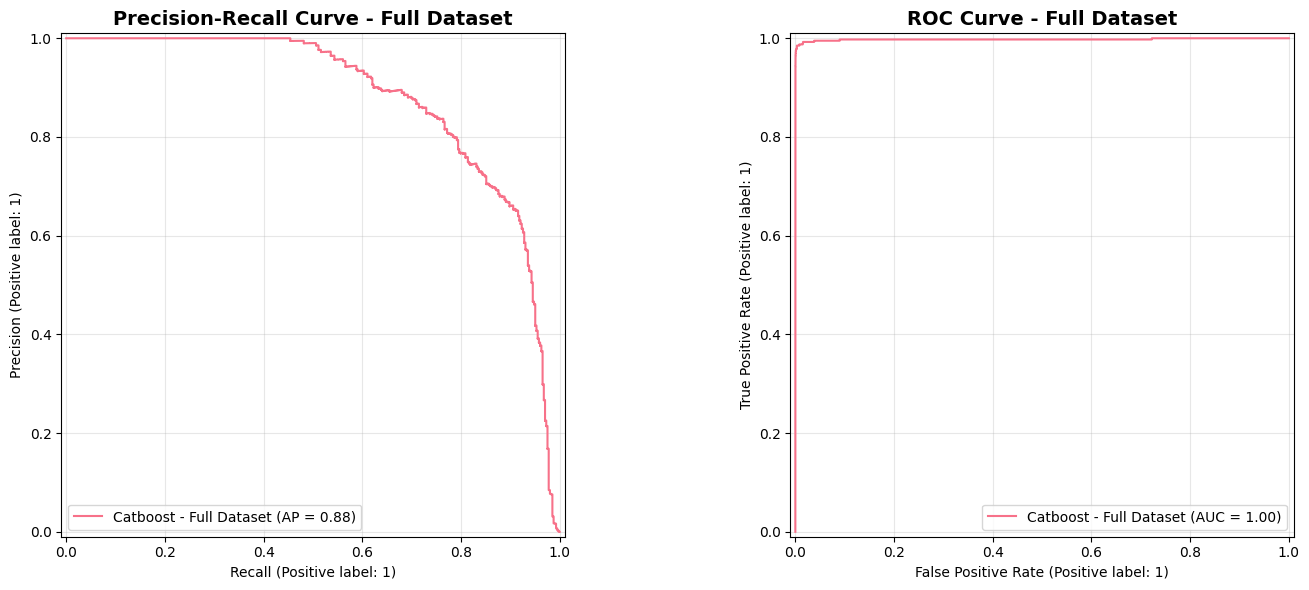

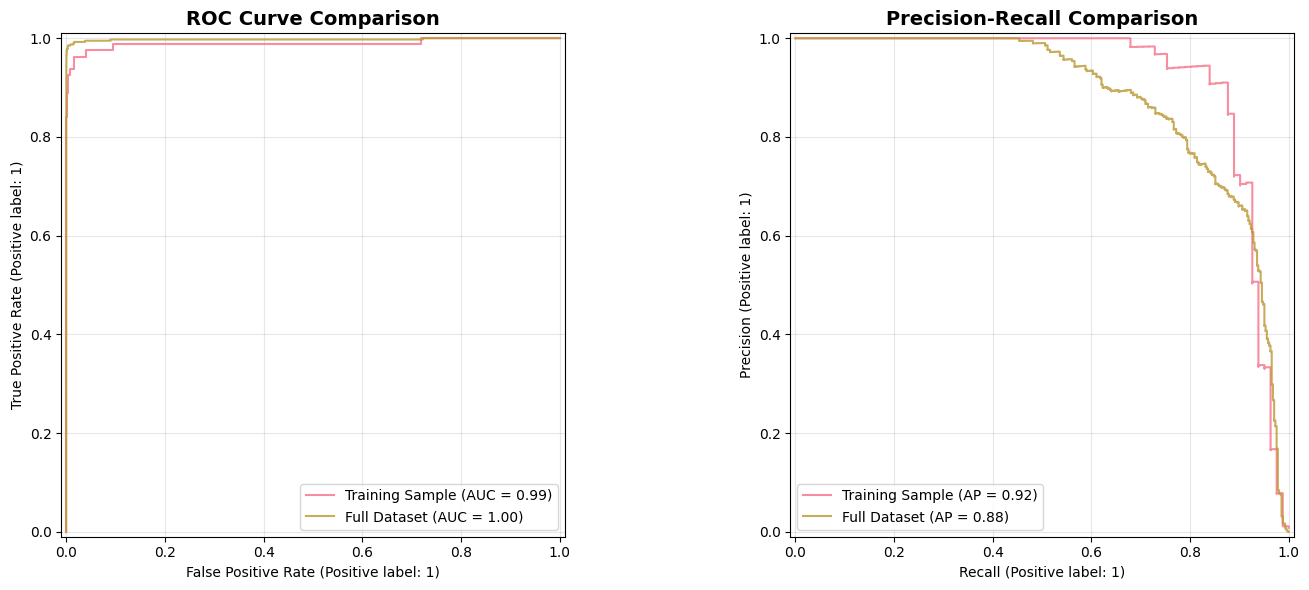

✅ Curvas de evaluación completas generadas


In [18]:
# 📈 **CURVAS ROC Y PRECISION-RECALL COMPLETAS**

if has_proba_full:
    print("\n📈 GENERANDO CURVAS COMPLETAS")
    print("=" * 35)

    # Crear subplots para las curvas completas
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Precision-Recall Curve
    pr_display_full = PrecisionRecallDisplay.from_predictions(
        y_full,
        y_proba_full,
        ax=axes[0],
        name=f"{best_model_name.replace('_', ' ').title()} - Full Dataset",
    )
    axes[0].set_title(
        "Precision-Recall Curve - Full Dataset", fontsize=14, fontweight="bold"
    )
    axes[0].grid(True, alpha=0.3)

    # ROC Curve
    roc_display_full = RocCurveDisplay.from_predictions(
        y_full,
        y_proba_full,
        ax=axes[1],
        name=f"{best_model_name.replace('_', ' ').title()} - Full Dataset",
    )
    axes[1].set_title("ROC Curve - Full Dataset", fontsize=14, fontweight="bold")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Comparación de curvas: Training vs Full
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ROC Comparison
    # Training curve (usando los datos del mejor modelo del entrenamiento)
    if hasattr(final_models[best_model_name], "predict_proba"):
        training_X_test = cv_results_all[best_model_name]["model_config"]["X_test"]
        training_y_proba = final_models[best_model_name].predict_proba(training_X_test)[
            :, 1
        ]

        RocCurveDisplay.from_predictions(
            y_test, training_y_proba, ax=axes[0], name="Training Sample", alpha=0.8
        )

    RocCurveDisplay.from_predictions(
        y_full, y_proba_full, ax=axes[0], name="Full Dataset", alpha=0.8
    )
    axes[0].set_title("ROC Curve Comparison", fontsize=14, fontweight="bold")
    axes[0].grid(True, alpha=0.3)

    # Precision-Recall Comparison
    if hasattr(final_models[best_model_name], "predict_proba"):
        PrecisionRecallDisplay.from_predictions(
            y_test, training_y_proba, ax=axes[1], name="Training Sample", alpha=0.8
        )

    PrecisionRecallDisplay.from_predictions(
        y_full, y_proba_full, ax=axes[1], name="Full Dataset", alpha=0.8
    )
    axes[1].set_title("Precision-Recall Comparison", fontsize=14, fontweight="bold")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✅ Curvas de evaluación completas generadas")
else:
    print("⚠️ Modelo no soporta probabilidades - Curvas no disponibles")